# Segmentación de clientes con RFM y K-Means

## Objetivo

Desarrollar una segmentación de clientes que combine un scoring RFM
interpretable con K-Means, con el propósito de priorizar clientes y
descubrir perfiles de comportamiento comercial.

In [1]:
import sys
from pathlib import Path
import ipykernel

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from IPython.display import display

print("Python version: ", sys.version)
print("Executable: ", sys.executable)
print("Working directory: ", Path.cwd())
print("Numpy: ", np.__version__)
print("Pandas: ",pd.__version__)
print("Scikit-Learn: ",sklearn.__version__)
print("Matplotlib: ",matplotlib.__version__)
print("IP Python Kernel: ",ipykernel.__version__)

Python version:  3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Executable:  c:\Users\hecto\Documents\Proyectos\customer_intelligence\.venv\Scripts\python.exe
Working directory:  c:\Users\hecto\Documents\Proyectos\customer_intelligence\notebooks
Numpy:  2.5.1
Pandas:  3.0.3
Scikit-Learn:  1.9.0
Matplotlib:  3.11.1
IP Python Kernel:  7.3.0


## 1. Fuente analítica

El análisis utiliza el dataset Customer 360, que contiene una fila por cliente
y resume su comportamiento histórico hasta una fecha de corte determinada.

Se parte de este dataset porque ya incorpora la limpieza, validación y
reconciliación de cancelaciones desarrolladas previamente. De esta manera,
RFM y K-Means se construirán sobre la misma base analítica.

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = (PROJECT_ROOT / "data" / "processed" / "customer_360.parquet")

customer_360 = pd.read_parquet(DATA_PATH)

print("Data path: ", DATA_PATH)
print("Shape: ", customer_360.shape)
print("Columns: ", customer_360.columns)

customer_360.head()

Data path:  c:\Users\hecto\Documents\Proyectos\customer_intelligence\data\processed\customer_360.parquet
Shape:  (5859, 11)
Columns:  Index(['customer_id', 'snapshot_date', 'first_purchase_date',
       'last_purchase_date', 'order_count', 'total_spend', 'total_items',
       'unique_products', 'recency_days', 'tenure_days',
       'average_order_value'],
      dtype='str')


,customer_id,snapshot_date,first_purchase_date,last_purchase_date,order_count,total_spend,total_items,unique_products,recency_days,tenure_days,average_order_value
0,12346,2011-12-10,2009-12-14 08:34:00,2010-06-28 13:53:00,11,368.36,69,26,530,726,33.487273
1,12347,2011-12-10,2010-10-31 14:20:00,2011-12-07 15:52:00,8,4921.53,2967,126,3,405,615.191250
2,12348,2011-12-10,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2019.40,2714,25,76,439,403.880000
3,12349,2011-12-10,2010-04-29 13:20:00,2011-11-21 09:51:00,4,4428.69,1624,138,19,590,1107.172500
4,12350,2011-12-10,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,17,311,311,334.400000


## 2. Selección y validación de variables

K-Means será entrenado con las tres dimensiones originales del análisis RFM:

- **Recency:** días desde la última compra.
- **Frequency:** cantidad de pedidos realizados.
- **Monetary:** gasto histórico total.

Se utilizan las métricas continuas originales y no los scores RFM de 1 a 5,
porque discretizar los valores eliminaría información relevante para calcular
las distancias entre clientes.

El identificador del cliente no participa en el entrenamiento, ya que identifica
una entidad pero no representa un comportamiento.

In [3]:
CANDIDATE_FEATURES = ["order_count", "total_spend", "total_items", "unique_products", "recency_days", "tenure_days", "average_order_value"]

if customer_360["customer_id"].duplicated().any():
    raise ValueError("Customer IDs must be unique")

candidate_features = (customer_360.set_index("customer_id")[CANDIDATE_FEATURES].copy())

if candidate_features.isna().any().any():
    raise ValueError("Candidate features cannot contain missig values")

if candidate_features.lt(0).any().any():
    raise ValueError("Candidate features cannot contain negative values")

if not np.isfinite(candidate_features.to_numpy(dtype=float)).all():
    raise ValueError("Candidate features must contain finite values")

feature_audit = pd.DataFrame(
    {
        "dtype": candidate_features.dtypes.astype(str),
        "missing": candidate_features.isna().sum(),
        "minimum": candidate_features.min(),
        "median": candidate_features.median(),
        "mean": candidate_features.mean(),
        "p95": candidate_features.quantile(0.95),
        "p99": candidate_features.quantile(0.99),
        "maximum": candidate_features.max(),
        "skewness": candidate_features.skew(),
    }
)

print("Customers: ", f"{len(candidate_features):,}")
print("Duplicate customer IDs: ", customer_360["customer_id"].duplicated().sum(),)

feature_audit.round(2)



Customers:  5,859
Duplicate customer IDs:  0


,dtype,missing,minimum,median,mean,p95,p99,maximum,skewness
order_count,int64,0,1.0,3.00,6.25,21.00,46.00,388.00,12.41
total_spend,float64,0,2.9,854.13,2839.60,8997.30,27001.15,578408.64,26.52
total_items,int64,0,1.0,476.00,1720.78,5225.00,16178.58,365114.00,23.25
unique_products,int64,0,1.0,44.00,81.73,281.00,502.84,2510.00,6.18
recency_days,int64,0,1.0,96.00,201.89,626.00,727.00,739.00,0.89
tenure_days,int64,0,1.0,531.00,475.36,736.00,739.00,739.00,-0.62
average_order_value,float64,0,2.9,275.01,363.30,871.56,1865.67,19809.75,16.68


### 2.1 Distribuciones y asimetría

K-Means calcula distancias entre observaciones y, por lo tanto, es sensible a
variables con distribuciones muy asimétricas y valores extremos.

Se evaluará la transformación `log1p`, que comprime los valores elevados sin
eliminar clientes. La comparación permitirá decidir qué variables deben
transformarse antes de estandarizarlas.

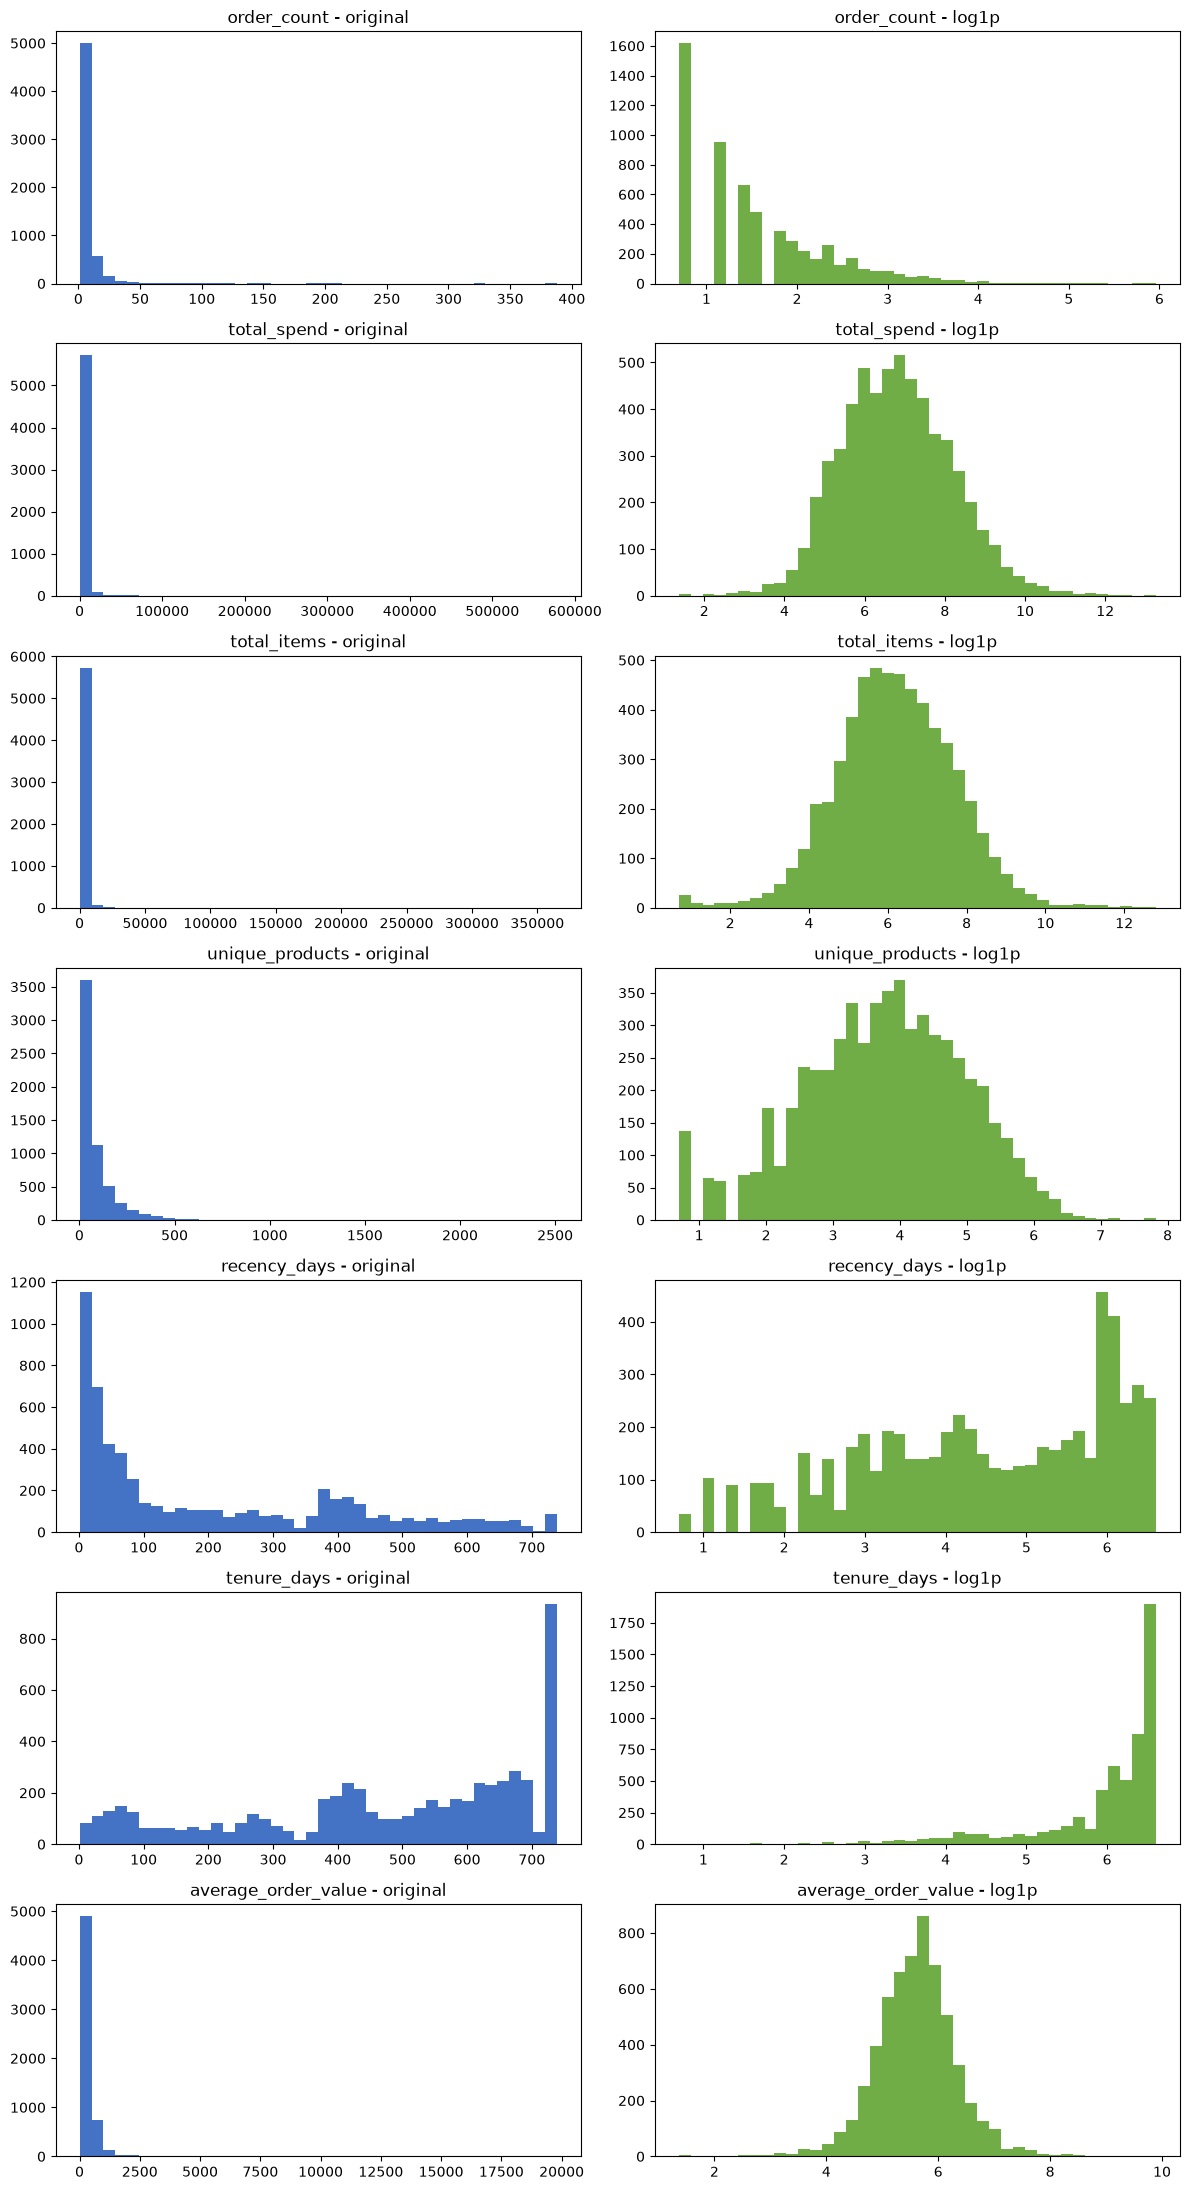

,original,after log1p,absolute_improvement
order_count,12.41,1.00,11.41
total_spend,26.52,0.24,26.28
total_items,23.25,-0.10,23.16
unique_products,6.18,-0.28,5.91
recency_days,0.89,-0.45,0.44
tenure_days,-0.62,-2.03,-1.41
average_order_value,16.68,-0.10,16.59


In [4]:
log_candidate_features = np.log1p(candidate_features)

skewness_comparisson = pd.DataFrame(
    {
        "original": candidate_features.skew(),
        "after log1p": log_candidate_features.skew(),
    }
)

skewness_comparisson["absolute_improvement"] = (skewness_comparisson["original"].abs() - skewness_comparisson["after log1p"].abs())

fig, axes = plt.subplots(nrows=len(CANDIDATE_FEATURES), ncols=2, figsize=(12,22))

for row, feature in enumerate(CANDIDATE_FEATURES):
    axes[row, 0].hist(candidate_features[feature], bins=40, color="#4472C4")

    axes[row, 0].set_title(f"{feature} - original")

    axes[row,1].hist(log_candidate_features[feature], bins=40, color ="#70AD47")

    axes[row, 1].set_title(f"{feature} - log1p")

plt.tight_layout()
plt.show()

skewness_comparisson.round(2)

### 2.2 Transformación preliminar y correlaciones

La transformación `log1p` redujo la asimetría absoluta de seis de las siete
variables candidatas. Por este motivo, se aplicará a dichas variables.

`tenure_days` permanecerá sin transformación porque `log1p` incrementó su
asimetría.

Antes de definir las variables finales del modelo se analizarán las
correlaciones en el espacio transformado. Una correlación elevada puede indicar
que dos variables representan comportamientos similares y podrían asignarles
un peso excesivo dentro de las distancias de K-Means.

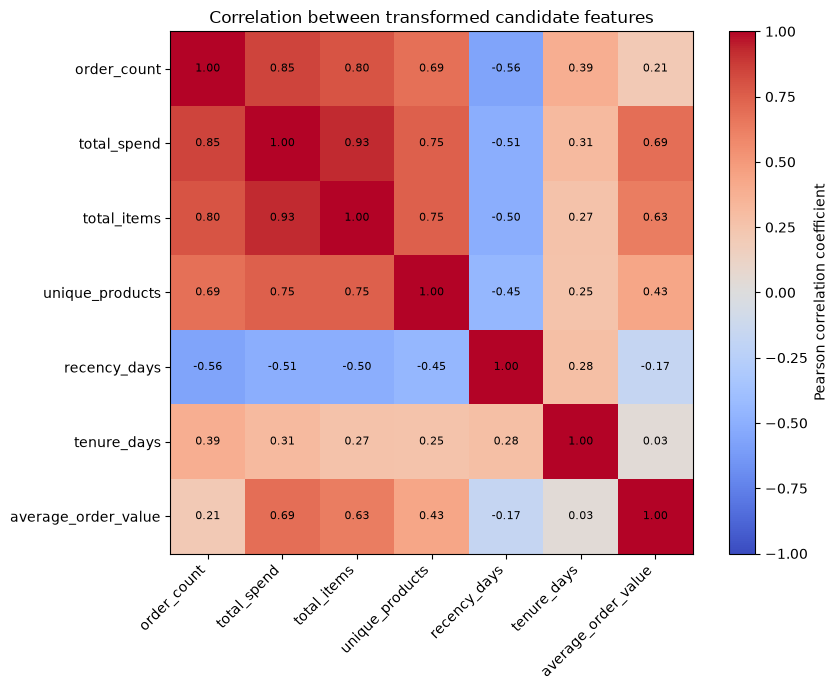

,order_count,total_spend,total_items,unique_products,recency_days,tenure_days,average_order_value
order_count,1.00,0.85,0.80,0.69,-0.56,0.39,0.21
total_spend,0.85,1.00,0.93,0.75,-0.51,0.31,0.69
total_items,0.80,0.93,1.00,0.75,-0.50,0.27,0.63
unique_products,0.69,0.75,0.75,1.00,-0.45,0.25,0.43
recency_days,-0.56,-0.51,-0.50,-0.45,1.00,0.28,-0.17
tenure_days,0.39,0.31,0.27,0.25,0.28,1.00,0.03
average_order_value,0.21,0.69,0.63,0.43,-0.17,0.03,1.00


In [5]:
LOG_FEATURES = ["order_count", "total_spend", "total_items", "unique_products", "recency_days", "tenure_days", "average_order_value"]

transformed_candidates = candidate_features.copy()
transformed_candidates[LOG_FEATURES] = np.log1p(transformed_candidates[LOG_FEATURES])

correlation_matrix = transformed_candidates.corr()

fig,ax = plt.subplots(figsize=(9,7))

image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_matrix.index)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.index)

for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        ax.text(column, row, f"{correlation_matrix.iloc[row, column]:.2f}", ha = "center", va= "center", fontsize=8)

fig.colorbar(image, ax=ax, label= "Pearson correlation coefficient")
ax.set_title("Correlation between transformed candidate features")

plt.tight_layout()
plt.show()

correlation_matrix.round(2)

### 2.3 Selección final de variables

La matriz de correlaciones mostró que `total_items` presenta una relación muy elevada con `total_spend` y `order_count`. Para evitar representar varias veces el mismo comportamiento, se excluye del entrenamiento.

`average_order_value` también se excluye porque se deriva de `total_spend` y `order_count`. Ambas variables excluidas se conservarán para describir los clusters después del entrenamiento.

El modelo utilizará las variables Recencia, Frecuencia de compra, Valor monetario, Antigüedad de la relación y Variedad de productos.

Aunque frecuencia y valor monetario están correlacionados, ambos se conservan porque representan conceptos comerciales fundamentales y distintos dentro del scoring de clientes.

In [6]:
MODEL_FEATURES = ["recency_days", "order_count", "total_spend", "tenure_days", "unique_products"]

MODEL_LOG_FEATURES = ["recency_days", "order_count", "total_spend", "unique_products"]

PROFILING_ONLY_FEATURES = ["total_items", "average_order_value"]

model_features = candidate_features[MODEL_FEATURES].copy()

transformed_model_features = model_features.copy()

transformed_model_features[MODEL_LOG_FEATURES] = np.log1p(transformed_model_features[MODEL_LOG_FEATURES])

print("Model features: ", MODEL_FEATURES)
print("Log transformed features: ", MODEL_LOG_FEATURES)
print("Profilling only features: ", PROFILING_ONLY_FEATURES)

transformed_model_features.describe().T.round(2)

Model features:  ['recency_days', 'order_count', 'total_spend', 'tenure_days', 'unique_products']
Log transformed features:  ['recency_days', 'order_count', 'total_spend', 'unique_products']
Profilling only features:  ['total_items', 'average_order_value']


,count,mean,std,min,25%,50%,75%,max
recency_days,5859.0,4.47,1.53,0.69,3.30,4.57,5.94,6.61
order_count,5859.0,1.55,0.81,0.69,0.69,1.39,2.08,5.96
total_spend,5859.0,6.80,1.38,1.36,5.82,6.75,7.70,13.27
tenure_days,5859.0,475.36,223.08,1.00,314.00,531.00,669.00,739.00
unique_products,5859.0,3.76,1.22,0.69,3.00,3.81,4.64,7.83


## 3. Preprocesamiento para K-Means

K-Means utiliza distancias euclidianas. Por eso, una variable con valores
numéricamente mayores podría dominar la formación de los clusters aunque no
fuera más importante para el negocio.

El preprocesamiento realizará dos operaciones:

1. Aplicar `log1p` a las cuatro variables cuya asimetría disminuyó.
2. Estandarizar las cinco variables para que tengan media cercana a cero y
   desviación estándar cercana a uno.

Las transformaciones se encapsulan en un pipeline de scikit-learn para que el
procedimiento sea reproducible y pueda reutilizarse posteriormente.

In [7]:
log_pipeline = Pipeline(steps=[("log1p",FunctionTransformer(np.log1p,feature_names_out="one-to-one",),),("scaler", StandardScaler())])

preprocessor = ColumnTransformer(transformers=[("log_features",log_pipeline,MODEL_LOG_FEATURES,),("scale_only",StandardScaler(),["tenure_days"],),],remainder="drop",verbose_feature_names_out=False,)

preprocessed_array = preprocessor.fit_transform(model_features)

preprocessed_features = pd.DataFrame(preprocessed_array, columns = preprocessor.get_feature_names_out(), index=model_features.index)

preprocessed_features = preprocessed_features[MODEL_FEATURES]

preprocessing_summary = pd.DataFrame(
    {
        "mean": preprocessed_features.mean(),
        "standard_deviation": preprocessed_features.std(),
        "minimum": preprocessed_features.min(),
        "maximum": preprocessed_features.max()
    }
)

preprocessing_summary.round(2)

,mean,standard_deviation,minimum,maximum
recency_days,0.0,1.0,-2.47,1.39
order_count,-0.0,1.0,-1.06,5.47
total_spend,-0.0,1.0,-3.94,4.69
tenure_days,0.0,1.0,-2.13,1.18
unique_products,0.0,1.0,-2.52,3.34


## 4. Evaluación de la cantidad de clusters

Se entrenarán modelos entre 2 y 8 clusters. La selección se basará en inercia, silhouette y tamaño de los grupos, junto con su interpretación comercial.

In [8]:
candidate_models = {}
evaluation_rows = []

for number_of_clusters in range(2,9):
    model = KMeans(n_clusters = number_of_clusters, random_state= 42, n_init =20)

    labels = model.fit_predict(preprocessed_features)

    cluster_shares = (pd.Series(labels).value_counts(normalize=True))

    evaluation_rows.append(
        {
            "number_of_clusters": number_of_clusters,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(preprocessed_features, labels),
            "smallest_cluster_pct": (cluster_shares.min() * 100),
            "largest_cluster_pct": (cluster_shares.max() * 100)
        }
    )

    candidate_models[number_of_clusters] = model

model_evaluation = (pd.DataFrame(evaluation_rows).set_index("number_of_clusters"))

model_evaluation.round(3)

,inertia,silhouette,smallest_cluster_pct,largest_cluster_pct
number_of_clusters,,,,
2,17093.116,0.354,41.662,58.338
3,12953.056,0.334,23.895,41.304
4,10487.658,0.294,21.010,29.852
5,9278.196,0.282,14.098,26.472
6,8332.000,0.249,9.968,23.059
7,7715.996,0.230,7.237,19.986
8,7235.061,0.232,7.203,18.945


### 4.1 Candidatos y estabilidad

Dos clusters obtienen la mayor silhouette, pero podrían producir una
segmentación demasiado general para la toma de decisiones.

Tres clusters mantienen una separación similar y tamaños equilibrados. Cuatro
clusters aportan mayor detalle, aunque presentan una silhouette menor.

Por este motivo se conservarán 2, 3 y 4 clusters como candidatos. Se evaluará
su estabilidad repitiendo el entrenamiento con diferentes semillas aleatorias.

La estabilidad se medirá mediante Adjusted Rand Index (ARI). Un valor cercano
a 1 indica que diferentes inicializaciones producen prácticamente la misma
segmentación.

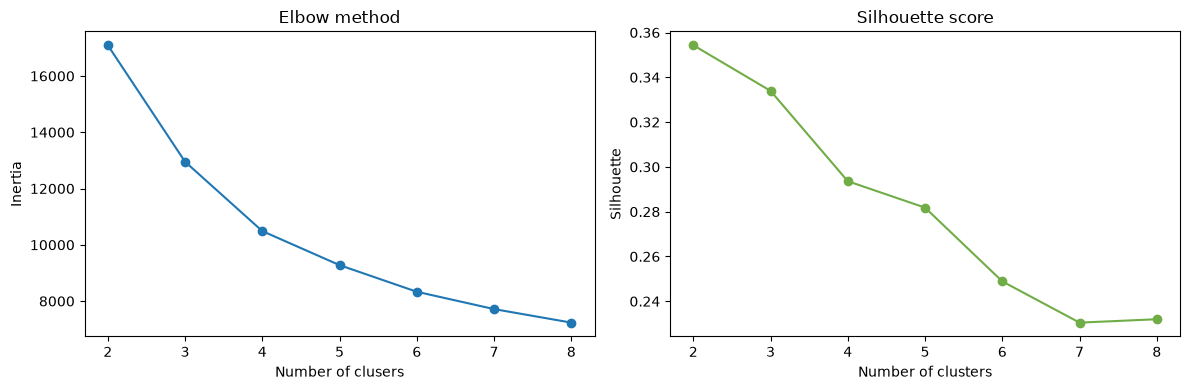

,mean_ari,min_ari,max_ari
number_of_clusters,,,
2,0.997,0.997,0.997
2,0.996,0.994,0.997
2,0.995,0.993,0.997
2,0.995,0.993,0.997
2,0.995,0.993,0.997
2,0.994,0.990,0.997
2,0.995,0.990,0.999
2,0.995,0.990,0.999
2,0.995,0.990,0.999


In [9]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

axes[0].plot(model_evaluation.index, model_evaluation["inertia"], marker="o")

axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusers")
axes[0].set_ylabel("Inertia")




axes[1].plot(model_evaluation.index, model_evaluation["silhouette"], marker="o", color = "#70AD47")

axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette")


plt.tight_layout()
plt.show()

CANDIDATE_CLUSTER_COUNTS = [2,3,4]
RANDOM_STATES = range(10)

stability_rows = []

for number_of_clusters in CANDIDATE_CLUSTER_COUNTS:
    reference_labels = candidate_models[number_of_clusters].labels_

    stability_scores = []

    for random_state in RANDOM_STATES:
        comparison_model = KMeans(n_clusters = number_of_clusters, random_state = random_state, n_init=20)

        comparison_labels = comparison_model.fit_predict(preprocessed_features)

        stability_scores.append(adjusted_rand_score(reference_labels, comparison_labels))

        stability_rows.append({
            "number_of_clusters": number_of_clusters,
            "mean_ari" : np.mean(stability_scores),
            "min_ari": np.min(stability_scores),
            "max_ari": np.max(stability_scores)
        })

stability_evaluation = pd.DataFrame(stability_rows).set_index("number_of_clusters")

stability_evaluation.round(3)

In [10]:
CANDIDATE_CLUSTER_COUNTS = [2, 3, 4]
RANDOM_STATES = range(10)

stability_rows = []

for number_of_clusters in CANDIDATE_CLUSTER_COUNTS:
    reference_labels = candidate_models[number_of_clusters].labels_

    stability_scores = []

    for random_state in RANDOM_STATES:
        comparison_model = KMeans(n_clusters=number_of_clusters, random_state=random_state, n_init=20)

        comparison_labels = comparison_model.fit_predict(preprocessed_features)

        stability_scores.append(adjusted_rand_score(reference_labels, comparison_labels))

    stability_rows.append(
        {
            "number_of_clusters": number_of_clusters,
            "mean_ari": np.mean(stability_scores),
            "minimum_ari": np.min(stability_scores),
            "maximum_ari": np.max(stability_scores)
        }
    )

stability_evaluation = pd.DataFrame(stability_rows).set_index("number_of_clusters")

stability_evaluation.round(3)

,mean_ari,minimum_ari,maximum_ari
number_of_clusters,,,
2,0.994,0.985,0.999
3,0.999,0.996,1.000
4,0.997,0.988,0.999


### 4.2 Comparación de perfiles comerciales

Los tres candidatos presentan una estabilidad elevada. La selección final no
se basará solamente en métricas geométricas: también debe producir grupos
diferenciados, comprensibles y accionables para negocio.

Los perfiles se calcularán utilizando las variables originales de Customer 360,
no sus versiones transformadas y estandarizadas.

Los identificadores numéricos de los clusters son arbitrarios: un cluster con
ID mayor no representa necesariamente un cliente de mayor valor.

In [11]:
candidate_profiles = {}

for number_of_clusters in CANDIDATE_CLUSTER_COUNTS:
    profile_data = customer_360.set_index("customer_id").copy()

    cluster_labels = pd.Series(candidate_models[number_of_clusters].labels_, index=model_features.index, name="cluster_id")

    profile_data = profile_data.join(cluster_labels)

    profile = profile_data.groupby("cluster_id").agg(
        customers=("snapshot_date", "size"),
        total_spend=("total_spend", "sum"),
        median_recency_days=("recency_days", "median"),
        median_order_count=("order_count", "median"),
        median_total_spend=("total_spend", "median"),
        median_tenure_days=("tenure_days", "median"),
        median_unique_products=("unique_products", "median"),
        median_total_items=("total_items", "median"),
        median_average_order_value=("average_order_value", "median")
    )

    profile["customer_share_pct"] = (
        profile["customers"] / len(profile_data) * 100
    )

    profile["spend_share_pct"] = (
        profile["total_spend"]
        / profile_data["total_spend"].sum()
        * 100
    )

    profile = profile[
        [
            "customers",
            "customer_share_pct",
            "total_spend",
            "spend_share_pct",
            "median_recency_days",
            "median_order_count",
            "median_total_spend",
            "median_tenure_days",
            "median_unique_products",
            "median_total_items",
            "median_average_order_value"
        ]
    ].sort_values("median_total_spend", ascending=False)

    candidate_profiles[number_of_clusters] = profile

    print(f"\n{number_of_clusters} CLUSTERS")
    display(profile.round(2))


2 CLUSTERS


,customers,customer_share_pct,total_spend,spend_share_pct,median_recency_days,median_order_count,median_total_spend,median_tenure_days,median_unique_products,median_total_items,median_average_order_value
cluster_id,,,,,,,,,,,
0,2441,41.66,14699520.24,88.35,31.0,8.0,2632.17,647.0,116.0,1557.0,330.28
1,3418,58.34,1937679.86,11.65,274.5,2.0,391.30,422.0,23.0,219.0,226.49



3 CLUSTERS


,customers,customer_share_pct,total_spend,spend_share_pct,median_recency_days,median_order_count,median_total_spend,median_tenure_days,median_unique_products,median_total_items,median_average_order_value
cluster_id,,,,,,,,,,,
2,2039,34.80,14047001.50,84.43,31.0,9.0,3119.33,661.0,128.0,1807.0,333.45
1,1400,23.89,1109395.45,6.67,39.0,2.0,550.52,127.0,32.0,325.0,264.68
0,2420,41.30,1480803.15,8.90,400.5,2.0,396.21,551.0,23.0,216.0,221.62



4 CLUSTERS


,customers,customer_share_pct,total_spend,spend_share_pct,median_recency_days,median_order_count,median_total_spend,median_tenure_days,median_unique_products,median_total_items,median_average_order_value
cluster_id,,,,,,,,,,,
1,1231,21.01,12312456.06,74.01,18.0,13.0,4734.26,683.0,172.0,2760.0,357.93
0,1749,29.85,2773201.48,16.67,162.0,4.0,1198.30,619.0,62.0,673.0,297.31
3,1244,21.23,1026008.00,6.17,33.0,2.0,556.88,101.5,32.0,329.0,269.40
2,1635,27.91,525534.57,3.16,424.0,1.0,252.88,480.0,15.0,131.0,182.46


## 5. Selección y entrenamiento del modelo final

Se seleccionan cuatro clusters como solución final.

Dos clusters producen una división demasiado general entre clientes de mayor
y menor actividad. Tres clusters distinguen clientes recientes e inactivos,
pero mantienen agrupados perfiles de alto valor y valor intermedio.

Cuatro clusters permiten separar estos comportamientos adicionales, mantienen
tamaños equilibrados y presentan una estabilidad elevada. La disminución de
silhouette se acepta como una compensación razonable por una mayor utilidad
comercial.

La selección combina calidad estadística, estabilidad e interpretación de
negocio.

In [12]:
FINAL_NUMBER_OF_CLUSTERS = 4

segmentation_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("kmeans", KMeans(n_clusters=FINAL_NUMBER_OF_CLUSTERS, random_state=42, n_init=20))
    ]
)

final_cluster_labels = segmentation_pipeline.fit_predict(model_features)

cluster_assignments = pd.Series(final_cluster_labels, index=model_features.index, name="cluster_id")

customer_segmentation = (customer_360.set_index("customer_id").join(cluster_assignments).reset_index())

if customer_segmentation["customer_id"].duplicated().any():
    raise ValueError("Customer IDs must remain unique")

if customer_segmentation["cluster_id"].isna().any():
    raise ValueError("Every customer must be assigned to a cluster")

final_preprocessed_features = segmentation_pipeline.named_steps["preprocessor"].transform(model_features)

final_silhouette = silhouette_score(final_preprocessed_features, final_cluster_labels)

final_cluster_summary = (customer_segmentation["cluster_id"].value_counts().sort_index().rename("customers").to_frame())

final_cluster_summary["customer_share_pct"] = (final_cluster_summary["customers"] / len(customer_segmentation) * 100)

print("Customers: ", f"{len(customer_segmentation):,}")
print("Final silhouette: ", f"{final_silhouette:.3f}")

final_cluster_summary.round(2)

Customers:  5,859
Final silhouette:  0.294


,customers,customer_share_pct
cluster_id,,
0,1749,29.85
1,1231,21.01
2,1635,27.91
3,1244,21.23


## 6. Interpretación comercial de los clusters

Los identificadores de K-Means son arbitrarios, por lo que se reemplazan por
nombres empresariales construidos a partir de los perfiles observados.

- **Alto valor consolidado:** clientes frecuentes, recientes y responsables de
  una elevada proporción del gasto.
- **Valor intermedio en seguimiento:** clientes establecidos con valor medio y
  una recencia que justifica seguimiento comercial.
- **Desarrollo reciente:** clientes nuevos o recientes con pocas compras y
  potencial para ampliar la relación.
- **Baja actividad prolongada:** clientes con poca frecuencia, bajo valor y un
  periodo extenso sin compras.

Las acciones sugeridas orientan la priorización comercial, pero no representan
efectos causales garantizados.

In [13]:
CLUSTER_NAMES = {
    0: "Valor intermedio en seguimiento",
    1: "Alto valor consolidado",
    2: "Baja actividad prolongada",
    3: "Desarrollo reciente"
}

CLUSTER_ACTIONS = {
    0: "Seguimiento y reactivación selectiva",
    1: "Retención prioritaria y desarrollo de valor",
    2: "Reactivación de bajo costo o despriorización",
    3: "Impulsar una segunda compra y ampliar la relación"
}

customer_segmentation["ml_segment"] = customer_segmentation["cluster_id"].map(CLUSTER_NAMES)

customer_segmentation["recommended_action"] = customer_segmentation["cluster_id"].map(CLUSTER_ACTIONS)

if customer_segmentation["ml_segment"].isna().any():
    raise ValueError("Every cluster must have a corresponding segment name")

if customer_segmentation["recommended_action"].isna().any():
    raise ValueError("Every cluster must have a recommended action")

final_cluster_profile = customer_segmentation.groupby("cluster_id").agg(
    customers=("customer_id", "size"),
    total_spend=("total_spend", "sum"),
    median_recency_days=("recency_days", "median"),
    median_order_count=("order_count", "median"),
    median_total_spend=("total_spend", "median"),
    median_tenure_days=("tenure_days", "median"),
    median_unique_products=("unique_products", "median"),
    median_total_items=("total_items", "median"),
    median_average_order_value=("average_order_value", "median")
)
final_cluster_profile["customer_share_pct"] = (final_cluster_profile["customers"] / len(customer_segmentation) * 100)


final_cluster_profile["spend_share_pct"] = (final_cluster_profile["total_spend"] / customer_segmentation["total_spend"].sum() * 100)

final_cluster_profile.insert(0, "ml_segment", final_cluster_profile.index.map(CLUSTER_NAMES))

final_cluster_profile.insert(1, "recommended_action", final_cluster_profile.index.map(CLUSTER_ACTIONS))

final_cluster_profile.round(2)

,ml_segment,recommended_action,customers,total_spend,median_recency_days,median_order_count,median_total_spend,median_tenure_days,median_unique_products,median_total_items,median_average_order_value,customer_share_pct,spend_share_pct
cluster_id,,,,,,,,,,,,,
0,Valor intermedio en seguimiento,Seguimiento y reactivación selectiva,1749,2773201.48,162.0,4.0,1198.30,619.0,62.0,673.0,297.31,29.85,16.67
1,Alto valor consolidado,Retención prioritaria y desarrollo de valor,1231,12312456.06,18.0,13.0,4734.26,683.0,172.0,2760.0,357.93,21.01,74.01
2,Baja actividad prolongada,Reactivación de bajo costo o despriorización,1635,525534.57,424.0,1.0,252.88,480.0,15.0,131.0,182.46,27.91,3.16
3,Desarrollo reciente,Impulsar una segunda compra y ampliar la relación,1244,1026008.00,33.0,2.0,556.88,101.5,32.0,329.0,269.40,21.23,6.17


## 7. Comparación con el baseline RFM

RFM y K-Means cumplen funciones complementarias:

- RFM produce un ranking interpretable y segmentos definidos mediante reglas.
- K-Means descubre grupos de comportamiento utilizando múltiples dimensiones.
No se espera que ambas segmentaciones coincidan exactamente. La comparación

permitirá identificar relaciones, diferencias y el valor adicional aportado
por Machine Learning.

El Adjusted Rand Index se utilizará únicamente como medida de coincidencia
entre ambas particiones, no como métrica de calidad predictiva.

In [14]:
RFM_SCORING_PATH = PROJECT_ROOT / "data" / "processed" / "customer_scoring.parquet"

rfm_scoring = pd.read_parquet(RFM_SCORING_PATH)

comparison_data = customer_segmentation.merge(
    rfm_scoring[
        [
            "customer_id",
            "recency_score",
            "frequency_score",
            "monetary_score",
            "rfm_score",
            "segment"
        ]
    ],
    on="customer_id",
    how="left",
    validate="one_to_one"
)

comparison_data = comparison_data.rename(columns={"segment": "rfm_segment"})

if comparison_data["rfm_segment"].isna().any():
    raise ValueError("Every customer must have an RFM segment")

rfm_ml_ari = adjusted_rand_score(comparison_data["rfm_segment"], comparison_data["cluster_id"])

comparison_summary = comparison_data.groupby(["cluster_id", "ml_segment"]).agg(
    customers=("customer_id", "size"),
    median_rfm_score=("rfm_score", "median"),
    median_recency_score=("recency_score", "median"),
    median_frequency_score=("frequency_score", "median"),
    median_monetary_score=("monetary_score", "median")
)

rfm_distribution_by_ml = (pd.crosstab(comparison_data["ml_segment"], comparison_data["rfm_segment"], normalize="index") * 100)

print("RFM versus ML ARI: ", f"{rfm_ml_ari:.3f}")

display(comparison_summary.round(2))
display(rfm_distribution_by_ml.round(2))

RFM versus ML ARI:  0.455


,,customers,median_rfm_score,median_recency_score,median_frequency_score,median_monetary_score
cluster_id,ml_segment,,,,,
0,Valor intermedio en seguimiento,1749,10.0,3.0,3.0,4.0
1,Alto valor consolidado,1231,14.0,5.0,5.0,5.0
2,Baja actividad prolongada,1635,4.0,1.0,1.0,1.0
3,Desarrollo reciente,1244,8.0,4.0,2.0,2.0


rfm_segment,Alto valor,Base general,Inactividad prolongada,Incorporación reciente,Lealtad consolidada,Potencial de desarrollo,Riesgo de inactividad,Valor estratégico
ml_segment,,,,,,,,
Alto valor consolidado,0.81,0.00,0.00,0.00,13.48,0.16,1.71,83.83
Baja actividad prolongada,0.12,6.54,80.18,0.61,0.18,0.43,11.93,0.00
Desarrollo reciente,8.76,25.48,0.64,37.38,3.62,15.27,1.45,7.40
Valor intermedio en seguimiento,8.69,8.12,2.29,1.77,22.30,6.00,42.94,7.89


In [16]:
print("RFM versus ML ARI: ", f"{rfm_ml_ari:.3f}")

RFM versus ML ARI:  0.455


### 7.1 Conclusión de la comparación

El Adjusted Rand Index entre RFM y K-Means es `0.455`, lo que representa una
coincidencia moderada.

Los métodos coinciden claramente en los perfiles extremos:

- El cluster **Alto valor consolidado** contiene principalmente clientes de
  Valor estratégico y presenta una mediana RFM de 14.
- El cluster **Baja actividad prolongada** contiene principalmente clientes de
  Inactividad prolongada y presenta una mediana RFM de 4.

Las diferencias se concentran en los perfiles intermedios. K-Means incorpora
antigüedad y variedad de productos, por lo que reorganiza clientes que RFM
separa mediante reglas de recencia, frecuencia y valor.

Por lo tanto, ambos métodos se utilizarán conjuntamente:

- RFM como ranking interpretable y priorización individual.
- K-Means como segmentación comportamental y definición de estrategias
  comerciales.

## 8. Visualización ejecutiva de los segmentos

La siguiente visualización compara la participación de clientes con la
participación del gasto histórico de cada segmento. Esto permite identificar
qué grupos concentran valor económico y cuáles requieren acciones de desarrollo
o reactivación.

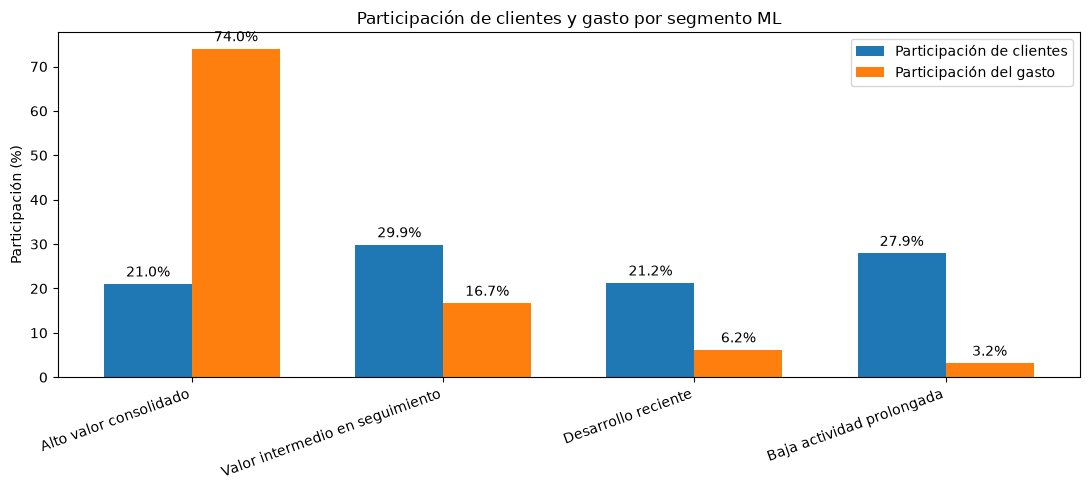

In [17]:
business_comparison = final_cluster_profile.sort_values("spend_share_pct", ascending=False).copy()

positions = np.arange(len(business_comparison))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

customer_bars = ax.bar(
    positions - bar_width / 2,
    business_comparison["customer_share_pct"],
    width=bar_width,
    label="Participación de clientes"
)

spend_bars = ax.bar(
    positions + bar_width / 2,
    business_comparison["spend_share_pct"],
    width=bar_width,
    label="Participación del gasto"
)

ax.set_xticks(positions)
ax.set_xticklabels(business_comparison["ml_segment"], rotation=20, ha="right")
ax.set_ylabel("Participación (%)")
ax.set_title("Participación de clientes y gasto por segmento ML")
ax.legend()

ax.bar_label(customer_bars, fmt="%.1f%%", padding=3)
ax.bar_label(spend_bars, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

## 9. Conclusiones y limitaciones

El modelo final utiliza cuatro clusters porque ofrece una segmentación comercial más detallada que las alternativas de dos y tres clusters, mantiene grupos equilibrados y presenta una estabilidad alta frente a distintas inicializaciones. El silhouette score de 0.294 indica una separación moderada, aceptable para datos de comportamiento de clientes donde los perfiles suelen solaparse.

La segmentación identifica cuatro perfiles accionables:

- **Alto valor consolidado:** representa el 21.0% de los clientes y concentra el 74.0% del gasto histórico.
- **Valor intermedio en seguimiento:** reúne clientes con relación estable, pero con mayor recencia y necesidad de seguimiento.
- **Desarrollo reciente:** agrupa clientes recientes sobre los que se busca impulsar una segunda compra y ampliar la relación.
- **Baja actividad prolongada:** contiene clientes de baja frecuencia, bajo valor y elevada recencia.

El ARI de 0.455 muestra una coincidencia moderada entre RFM y K-Means. Los dos enfoques coinciden claramente en los perfiles extremos, mientras que K-Means reorganiza los perfiles intermedios incorporando antigüedad y diversidad de productos. Por lo tanto, RFM se conserva como baseline explicable y K-Means se utiliza como segmentación multivariable complementaria.

El modelo tiene las siguientes limitaciones:

- La segmentación representa un único corte histórico y no demuestra impacto causal sobre ventas o retención.
- K-Means supone clusters aproximadamente compactos y utiliza distancias euclidianas.
- Los perfiles deben monitorearse si se incorporan nuevos periodos o cambia el comportamiento de los clientes.
- Los identificadores numéricos de los clusters son arbitrarios; los nombres comerciales deben asignarse mediante sus perfiles y no únicamente mediante el número del cluster.

La lógica validada en este notebook fue trasladada a un pipeline reutilizable y probado dentro del código fuente del proyecto.